In [4]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit, CustomNonbondedForce

from colloids import ColloidPotentialsAlgebraic, ColloidPotentialsParameters

import math

In [17]:
# Set particle sizes equal for a system of only one type of colloid
radius_positive = 105.0 * unit.nanometer
radius_negative = 105.0 * unit.nanometer

#Set surface charges to 0 - using neutral particles
surface_potential_positive = 0.0 * (unit.milli * unit.volt)
surface_potential_negative = -0.0 * (unit.milli * unit.volt)

brush_length=10.0 * unit.nanometer
brush_density=0.09 / (unit.nanometer ** 2)
temperature=298.0 * unit.kelvin
box_length = 1000* unit.nanometer

colloid_potential_parameters = ColloidPotentialsParameters(
    brush_density=0.09 / (unit.nanometer ** 2), brush_length=10.0 * unit.nanometer,
    debye_length=6.0 * unit.nanometer, temperature=298.0 * unit.kelvin,
    dielectric_constant=80.0)

phi = 0.5
radius_depletant = 5.0 * unit.nanometer

In [6]:
# get steric and electrostatic potentials
# the electrostatic potential will be zero because particles are not charged

def get_potentials(h_values, radius_one, radius_two, surface_potential_one, surface_potential_two, 
                   parameters, platform_name="Reference"):
    # Set up system.
    system = openmm.System()
    # Make system very large so that we do not care about periodic boundaries.
    side_length = 200.0 * (max(h_values) + radius_one.value_in_unit(unit.nanometer) + radius_two.value_in_unit(unit.nanometer)) 
    system.setDefaultPeriodicBoxVectors([side_length, 0.0, 0.0],
                                        [0.0, side_length, 0.0],
                                        [0.0, 0.0, side_length])
    colloid_potentials = ColloidPotentialsAlgebraic(
        colloid_potentials_parameters=parameters, use_log=False)
    
    # Add two particles to the system and forces (mass is unimportant for the potential energies).
    system.addParticle(mass=1.0)
    colloid_potentials.add_particle(radius=radius_one, surface_potential=surface_potential_one)
    system.addParticle(mass=1.0)
    colloid_potentials.add_particle(radius=radius_two, surface_potential=surface_potential_two)

    # Add forces.
    for potential in colloid_potentials.yield_potentials():
        system.addForce(potential)
        
    for force in system.getForces():
        print(f"Energy function: {force.getEnergyFunction()}")
        print(f"Nonbonded method: {force.getNonbondedMethod()}, Cutoff distance: {force.getCutoffDistance()}")
        assert force.usesPeriodicBoundaryConditions()
        assert not force.getUseLongRangeCorrection()
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    dummy_integrator = openmm.LangevinIntegrator(
        parameters.temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    
    potential_energies = np.zeros(len(h_values))
    for h_index, h_value in enumerate(h_values):
        context.setPositions([[(radius_one + radius_two).value_in_unit(unit.nanometer) + h_value, 0.0, 0.0], [0.0, 0.0, 0.0]])
        state = context.getState(getEnergy=True)
        potential_energies[h_index] = (
            state.getPotentialEnergy()
            / (unit.BOLTZMANN_CONSTANT_kB * parameters.temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies

Energy function: step(two_l - h) * steric_prefactor * rs / 2.0 * brush_length * brush_length * (28.0 * ((two_l / h)^0.25 - 1.0) + 20.0 / 11.0 * (1.0 - (h / two_l)^2.75)+ 12.0 * (h / two_l - 1.0)); h = r - rs;rs = radius1 + radius2;two_l = 2.0 * brush_length
Nonbonded method: 2, Cutoff distance: 230.00000000000006 nm
Energy function: electrostatic_prefactor * radius * psi1 * psi2 * exp(-h / debye_length); radius = 2.0 / (1.0 / radius1 + 1.0 / radius2);h = r - rs;rs = radius1 + radius2
Nonbonded method: 2, Cutoff distance: 336.0000000000001 nm
Using Reference platform.


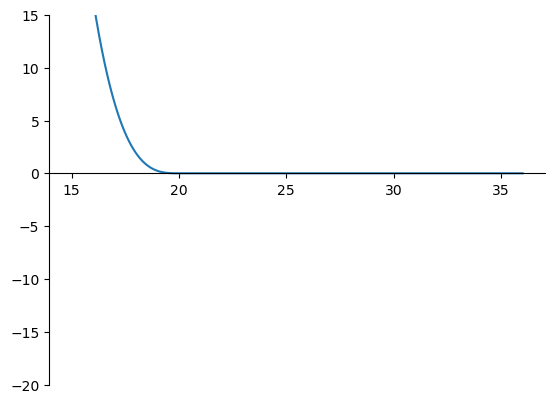

In [7]:
#plot steric and electrostatic potentials

h_vals = np.linspace(15.0, 36.0, num=1000)
potential_vals = get_potentials(h_vals, radius_positive, radius_negative, 
                                surface_potential_positive, surface_potential_negative,
                                colloid_potential_parameters)

plt.figure()
plt.plot(h_vals, potential_vals)
plt.ylim(-20, 15)

ax = plt.gca()
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
plt.show()
plt.close()

In [8]:
def expected_AO_potential(h_values, radius_colloid, brush_length, brush_density, phi, radius_depletant):

    #diameters 
    sigma_colloid = (2 * radius_colloid + 2*brush_length) #*unit.nanometer

    sigma_depletant = (2 * radius_depletant + 2*brush_length) #*unit.nanometer

    # size ratio 
    q = sigma_depletant/sigma_colloid 

    ## this analytical expression only works for q < 0.1547
    
    #surface-to-surface separation
    r = h + 2*radius_colloid + 2*brush_length
    
    if r <= (sigma_colloid + sigma_depletant):

        AO_prefactor = -phi * (1+q)**3/q**3

        term1 = 3*r / (2 * sigma_colloid * (1+q))

        term2 = r**3 / (2 * sigma_colloid**3 *(1+q)**3)


        AO_potential = (AO_prefactor * (1 - term1 + term2)) 
        
    else:
        
        AO_potential = 0.0 
        
    return AO_potential 

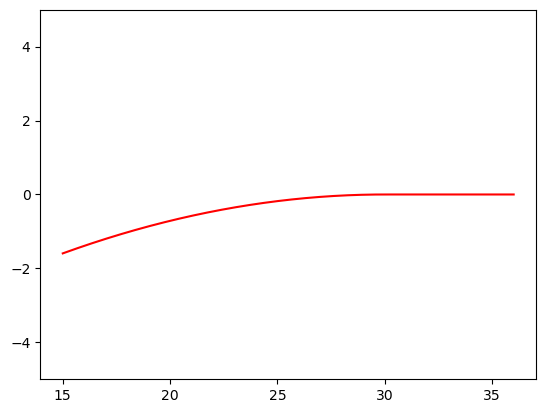

In [13]:
#r = h + 2*radius_colloid + 2*brush_length
h_vals = np.linspace(15.0, 36.0, num=1000) * unit.nanometer
r_vals = np.linspace(15.0 +  2*105 +20, 36.0 + 2*105+20, num=1000) * unit.nanometer

ao_vals_expected = []

for h in h_vals:
    
    ao = expected_AO_potential(h, radius_negative, brush_length, brush_density, 0.5, radius_depletant)

    ao_vals_expected.append(ao) 
    
plt.plot(h_vals, ao_vals_expected, color='red') #goes to zero when r > 260. r = h + 210 + 20 (i.e. h>30)
plt.ylim(-5,5)
plt.show()

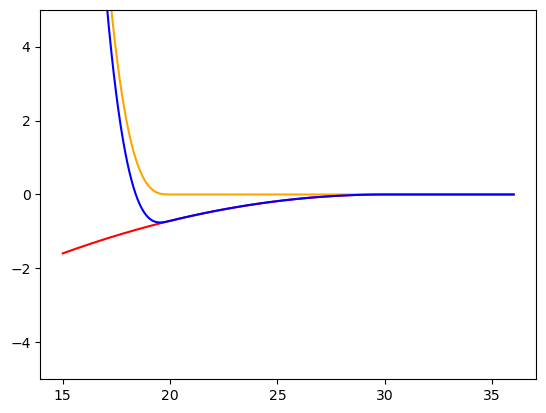

In [14]:
plt.plot(h_vals, ao_vals_expected, color='red') #goes to zero when r > 260. r = h + 210 + 20 (i.e. h>30)
plt.plot(h_vals, potential_vals, color = 'orange') #goes to zero when h > 2L (i.e. h >20)
plt.plot(h_vals, ao_vals_expected + potential_vals, color='blue') 

plt.ylim(-5,5)
plt.show()

In [18]:
def get_AO_potential(r_values, radius, box_length, brush_length, phi, radius_depletant, platform_name="Reference"):
    
    system = openmm.System()

    system.setDefaultPeriodicBoxVectors([box_length, 0.0, 0.0],
                                        [0.0, box_length, 0.0],
                                        [0.0, 0.0, box_length])
    
    
    temperature = 298.0 * unit.kelvin
    
    
    depletion_potential = CustomNonbondedForce(
        "step(sigma_colloid + sigma_depletant - r) * "
        "(AO_prefactor * (1 - term1 + term2));"
        "AO_prefactor =  -phi * (1+q)^3/q^3;"
        "term1 = 3*r/ (2 * sigma_colloid * (1+q));"
        "term2 = r^3 / (2 * sigma_colloid^3 *(1+q)^3);"
        "q = sigma_depletant/sigma_colloid;"
        "sigma_colloid = ((2 * radius) + 2*brush_length);"
        "sigma_depletant = ((2 * radius_depletant) + 2*brush_length);"
    )

    depletion_potential.addGlobalParameter("phi", phi)

    depletion_potential.addGlobalParameter("radius_depletant", radius_depletant)

    depletion_potential.addGlobalParameter("brush_length", brush_length)

    depletion_potential.addGlobalParameter("radius", radius)
    
    system.addParticle(mass=1.0)
    depletion_potential.addParticle()
    system.addParticle(mass=1.0)
    depletion_potential.addParticle()
    
    # Add forces.
    system.addForce(depletion_potential)
        
    for force in system.getForces():
        print(f"Energy function: {force.getEnergyFunction()}")
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    dummy_integrator = openmm.LangevinIntegrator(
        temperature, 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    
    potential_energies = np.zeros(len(r_values))
    for r_index, r_value in enumerate(r_values):
        #context.setPositions([[r_value*unit.nanometer-2*brush_length, 0.0, 0.0], [0.0, 0.0, 0.0]])
        context.setPositions([[r_value*unit.nanometer, 0.0, 0.0], [0.0, 0.0, 0.0]])
        state = context.getState(getEnergy=True)
        potential_energies[r_index] = (
            state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
            #/ (unit.BOLTZMANN_CONSTANT_kB *temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies
    

Energy function: step(sigma_colloid + sigma_depletant - r) * (AO_prefactor * (1 - term1 + term2));AO_prefactor =  -phi * (1+q)^3/q^3;term1 = 3*r/ (2 * sigma_colloid * (1+q));term2 = r^3 / (2 * sigma_colloid^3 *(1+q)^3);q = sigma_depletant/sigma_colloid;sigma_colloid = ((2 * radius) + 2*brush_length);sigma_depletant = ((2 * radius_depletant) + 2*brush_length);
Using Reference platform.


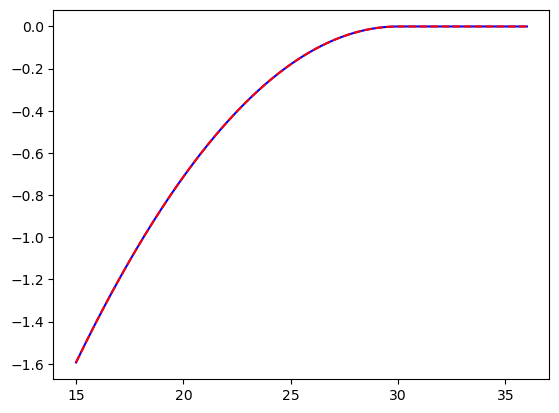

In [19]:
h_vals = np.linspace(15.0 , 36.0, num=1000)
r_vals = np.linspace(15.0 +  2*105 +20, 36.0 + 2*105+20, num=1000)
ao_vals = get_AO_potential(r_vals, radius_negative, box_length, brush_length, phi, radius_depletant)
plt.plot(h_vals, ao_vals, color='blue')
plt.plot(h_vals, ao_vals_expected, color='red', linestyle='--')
plt.show()

In [ ]:
'''def expected_AO_potential_1(r, radius1, radius2, brush_length, phi, rdep):
    """
    Return the Asakura-Oosawa potential (generalized to asymmetric sphere) for a colloidal solution in a 
    background of non-adsorbing polymers.
    
    h: surface-to-surface particle separation distance
    radius1: radius of first type of colloidal particle
    radius2: radius of second type of colloidal particle
    brush_length: length of polymer brush
    phi: volume fraction of polymer depletants (must be between 0 and 1)
    rdep: radius of polymer depletants
    
    """
    
       # if r <= (sigma_colloid + sigma_depletant):
      #  prefactor = -phi * (1+q)**3/q**3
      #  term1 = 3*r / (2 * sigma_colloid * (1+q))
      #  term2 = r**3 / (2 * sigma_colloid**3 *(1+q)**3)
        
    
    #diameters
    sigmaD1 = 2*brush_length + 2*radius1 
    sigmaD2 = 2*brush_length + 2*radius2
    
    
    rcc = r + radius1 + radius2
    #print(rcc)
    #print(sigmaD1/2 + sigmaD2/2 + 2*rdep)
    
    #h = radius1 + radius2 + r #center-to-center separation distance 
    
    q1 = radius1/rdep #ratio of particle sizes: colloid1 to polymer
    q2 = radius2/rdep ##ratio of particle sizes: colloid2 to polymer
    n = rcc/rdep

    return ( -phi/16 * np.where(rcc <= (sigmaD1/2 + sigmaD2/2 + 2*rdep),
                                    (q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2)),
                                    #(q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2)),
                                    0.0))'''